In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from skimage import io,color
from skimage.util import img_as_float

# Task-1: Applying FFT on 2D Image


(np.float64(-0.5), np.float64(473.5), np.float64(473.5), np.float64(-0.5))

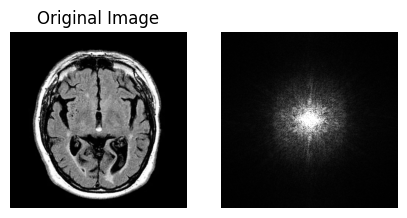

In [18]:
# Load grayscale image brain_mri.png and normalize
image = image = io.imread('brain_mri.png', as_gray=True)
image = img_as_float(image)

def perform_fft2(x, M, N):
    X = np.fft.fft2(x)
    X = np.fft.fftshift(X)
    X = X / (N * M)

    u = np.fft.fftshift(np.fft.fftfreq(M))
    v = np.fft.fftshift(np.fft.fftfreq(N))
    u, v = np.meshgrid(u, v)

    return X, u, v
# Perform FFT on the image

X, u, v = perform_fft2(image, image.shape[0], image.shape[1])

plt.figure(figsize=(5,5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.log(np.abs(X)+1), cmap='gray',vmin=0, vmax=np.percentile(np.log(np.abs(X)+1), 99))
# The extra argument is given because low frequency content is very dominating in the image.
# If we don't scale properly, we won't be able to visualize other frequency contents.

plt.axis('off')


# Lab Task 2: Filtering in the Frequency Domain


In [19]:
def apply_filter(H, X):
    filtered = X * H
    return np.abs(np.fft.ifft2(np.fft.ifftshift(filtered)))

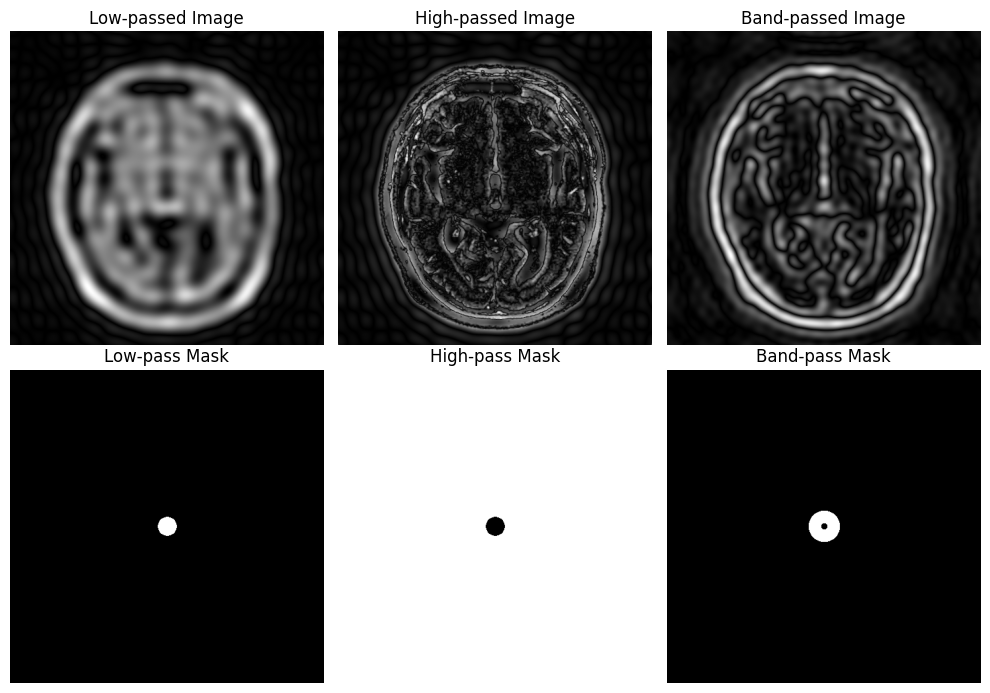

In [20]:
# Compute radial frequency grid
D = np.sqrt(u**2 + v**2)
#D = D / np.max(D)

cut_off = 0.03


# Define a low pass and a high pass filter with the given cut_off

H_lp = (D < cut_off).astype(float)

H_hp = (D > cut_off).astype(float)
# Define Band-pass filter with the given cut_offs
thres_low = 0.01
thres_high = 0.05


H_bp = ((D > thres_low) & (D < thres_high)).astype(float)
# Apply filter and reconstruct the filtered images
img_lp = apply_filter(H_lp, X)
img_hp = apply_filter(H_hp, X)
img_bp = apply_filter(H_bp, X)

plt.figure(figsize=(10, 7))

plt.subplot(2, 3, 1)
plt.imshow(img_lp, cmap='gray')
plt.title("Low-passed Image")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(img_hp, cmap='gray')
plt.title("High-passed Image")
plt.axis('off')

plt.subplot(2, 3,3)
plt.imshow(img_bp, cmap='gray')
plt.title("Band-passed Image")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(H_lp, cmap='gray')
plt.title("Low-pass Mask")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(H_hp, cmap='gray')
plt.title("High-pass Mask")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(H_bp, cmap='gray')
plt.title("Band-pass Mask")
plt.axis('off')

plt.tight_layout()
plt.show()